In [1]:
# Load anndata object and create pseudobulk for MOFA analysis
# Necessary cell annotations in the anndata object are: 'cluster_id' (giving the cell-type cluster annotations), 'sample_id' (unique identifier of a sample)

# Prerequisites - Load Libraries

In [84]:
from IPython.display import display, HTML

In [85]:
from MS1_Functions import popup_function_pos

In [86]:
from MS1_Functions import popup_function_info

In [87]:
from MS1_Functions import popup_function_neg

In [88]:
# Inform about execution start
popup_function_pos("01_Prepare_Pseudobulk.ipynb: Execution Started")

In [89]:
#pip install scanpy

In [90]:
#pip install anndata

In [91]:
import scanpy as sc

In [92]:
import anndata as  ad

In [93]:
import pandas as pd

In [94]:
import random

In [95]:
import numpy as np

In [96]:
import random

In [97]:
import os

In [98]:
#pip install decoupler

In [99]:
import decoupler as dc

In [100]:
import time

In [101]:
ad.__version__

'0.9.2'

In [102]:
import numba

In [103]:
print(numba.__version__)

0.53.1


In [104]:
np.__version__

'1.22.4'

In [105]:
import scanpy as sc
from scipy.sparse import issparse

In [106]:
import seaborn as sns
import matplotlib.pyplot as plt

In [107]:
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap

# Preqrequisites Configurations & Parameters

In [111]:
### Load the parameters that are set via the configuration files

In [112]:
### Load configurations file
global_configs = pd.read_csv('configurations/Data_Configs.csv', sep = ',')

In [113]:
global_configs

,parameter,value
0,data_path,/home/jovyan/visha-mofa-analysis-datavol-1/con...
1,result_path,/home/jovyan/visha-mofa-analysis-datavol-1/con...
2,configuration_name,CGS_v2


In [114]:
data_path = global_configs['value'][global_configs['parameter'] == 'data_path']

In [115]:
data_path

0    /home/jovyan/visha-mofa-analysis-datavol-1/con...
Name: value, dtype: object

In [116]:
result_path = global_configs['value'][global_configs['parameter'] == 'result_path']

In [117]:
result_path

1    /home/jovyan/visha-mofa-analysis-datavol-1/con...
Name: value, dtype: object

In [118]:
## Loading the file containing the name of the single-cell dataset

In [119]:
sc_configs = pd.read_csv('configurations/01_Pre_Processing_SC_Data.csv', sep = ',')

In [120]:
sc_configs

,data_name
0,Prepared_sc_Data


In [121]:
sc_configs = sc_configs[sc_configs['data_name'] != '']

In [122]:
sc_dataset_names = pd.unique(sc_configs['data_name'])

In [123]:
sc_dataset_names

array(['Prepared_sc_Data'], dtype=object)

In [124]:
### Generate the result data directory if it does not exist yet

if not os.path.exists(result_path[1] + '/01_results'):
    # Create the directory if it doesn't exist
    os.makedirs(result_path[1] + '/01_results')


# Load data

## Anndata object

In [125]:
### Load single-cell datasets as anndata format; should contain the meta-columns: sample_id; cluster_id
### Raw Counts should be given in default assay

In [126]:
sc_data_list = {}

In [ ]:
for i in sc_dataset_names:
    source_text = os.path.join(data_path[0], f'{i}'+ '.h5ad')
    
    if os.path.exists(source_text):
        print(source_text)
        print(os.path.getmtime(source_text))
        adata = ad.read_h5ad(source_text)
        #adata.raw.to_adata()

        # Store the loaded Seurat object in the dictionary
        sc_data_list[i] = adata
        popup_function_pos(" Data Loaded")
    else:
        print(f"The file '{  source_text}' does not exist.")
        popup_function_neg("Error: the single-cell data file could not be loaded - check the entered path and name of the dataset in the configuration files")

/home/jovyan/visha-mofa-analysis-datavol-1/conda_env/mofa_workflow/input_data/Prepared_sc_Data.h5ad
1720265082.663526


In [43]:
adata

AnnData object with n_obs × n_vars = 125052 × 26795
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'S.Score', 'G2M.Score', 'Phase', 'old.ident', 'nCount_HTO', 'nFeature_HTO', 'HTO_maxID', 'HTO_secondID', 'HTO_margin', 'HTO_classification', 'HTO_classification.global', 'hash.ID', 'CSclassification', 'Patient', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.3', 'seurat_clusters', 'Idents', 'cluster_id', 'sample_id'

In [44]:
adata.obs

,orig.ident,nCount_RNA,nFeature_RNA,percent.mt,S.Score,G2M.Score,Phase,old.ident,nCount_HTO,nFeature_HTO,...,hash.ID,CSclassification,Patient,nCount_SCT,nFeature_SCT,SCT_snn_res.0.3,seurat_clusters,Idents,cluster_id,sample_id
AAACCCAAGTTTGAGA-1_1,Pool1,795.0,294,0.125786,-0.019962,0.011491,G2M,Pool1,712.0,10,...,HTO-B0259,KS,KS35.2,933.0,294,0,0,T cells,T cells,KS35.2
AAACCCACACGGCCAT-1_1,Pool1,1144.0,494,0.786713,0.024574,-0.007187,S,Pool1,824.0,10,...,HTO-B0253,KS,KS32.1,1110.0,491,1,1,Regulatory T cells,Regulatory T cells,KS32.1
AAACCCACACTCTAGA-1_1,Pool1,1929.0,854,0.000000,-0.004932,0.062952,G2M,Pool1,1078.0,10,...,HTO-B0253,KS,KS32.1,1398.0,835,3,3,Classical Monocytes,Classical Monocytes,KS32.1
AAACCCAGTATCGATC-1_1,Pool1,999.0,366,1.001001,-0.023320,-0.029489,G1,Pool1,540.0,10,...,HTO-B0258,KS,KS35.1,1011.0,364,0,0,T cells,T cells,KS35.1
AAACCCAGTTCATCGA-1_1,Pool1,3731.0,1639,0.482444,-0.045330,-0.033605,G1,Pool1,2077.0,10,...,HTO-B0253,KS,KS32.1,1022.0,507,3,3,Classical Monocytes,Classical Monocytes,KS32.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTTGGTTACCTGA-1_12,Pool13,769.0,513,1.430429,0.051790,0.091853,G2M,Pool13,265.0,7,...,HTO-B0253,KS,KS36.3,876.0,513,6,6,Dendritic cells,Dendritic cells,KS36.3
TTTGTTGTCACCACAA-1_12,Pool13,2086.0,775,0.095877,-0.002443,0.072962,G2M,Pool13,576.0,7,...,HTO-B0254,KS,KS16.1,1414.0,750,0,0,T cells,T cells,KS16.1
TTTGTTGTCCCATAGA-1_12,Pool13,1331.0,797,0.601052,0.044174,-0.055285,S,Pool13,198.0,7,...,HTO-B0252,KS,KS23.1,1225.0,797,2,2,NK cells,NK cells,KS23.1
TTTGTTGTCGAGCCTG-1_12,Pool13,2440.0,1145,3.770492,0.089901,-0.030708,S,Pool13,744.0,7,...,HTO-B0256,KS,KS15.1,1554.0,1033,1,1,Regulatory T cells,Regulatory T cells,KS15.1


# Data-Checks

In [45]:
# Optional execute some checks to see whether raw counts will be used

In [46]:
### Check that data contains the required columns

In [47]:
if 'cluster_id' in adata.obs.columns and 'sample_id' in adata.obs.columns:
    print('Data correctly formatted')
else:
    print('cluster_id or sample_id meta data columns are missing in the anndata make sure to include them')
    popup_function_neg("Error: cluster_id or sample_id meta data columns are missing in the anndata make sure to include them")
    

Data correctly formatted


## Check amount of cells per sample and cluster

In [48]:
cell_counts_per_cluster = {key: pd.crosstab(value.obs['cluster_id'], value.obs['cluster_id']).sum(axis=1) for key, value in sc_data_list.items()}

In [49]:
### Amount of cells per cluster
cell_counts_per_cluster

{'Prepared_sc_Data': cluster_id
 T cells                           25712
 Regulatory T cells                24320
 NK cells                          19394
 Classical Monocytes               16361
 Activated T cells                 15643
 B Cells                            9058
 Dendritic cells                    7754
 Non-Classical Monocytes            2616
 Platelets                          1431
 Metabolically active Monocytes     1158
 Erythrocytes                        972
 Plasma cells                        633
 dtype: int64}

In [50]:
### Save the result as a dataframe for usage in the next script
cells_per_sample_cluster = {key: pd.crosstab(value.obs['cluster_id'], value.obs['sample_id']).T for key, value in sc_data_list.items()}

In [51]:
# Convert the dictionary of DataFrames into a single DataFrame and melt it to long format
cells_per_sample_cluster_long = pd.concat({key: value.melt(ignore_index=False) for key, value in cells_per_sample_cluster.items()})

# Reset index and rename columns
cells_per_sample_cluster_long.reset_index(inplace=True)
cells_per_sample_cluster_long.columns = ['dataset', 'Sample', 'Cluster_Cell_Type', 'amount_cells']

In [52]:
cells_per_sample_cluster_long

,dataset,Sample,Cluster_Cell_Type,amount_cells
0,Prepared_sc_Data,HF2,T cells,161
1,Prepared_sc_Data,HF3,T cells,412
2,Prepared_sc_Data,HF4,T cells,1
3,Prepared_sc_Data,HF5,T cells,327
4,Prepared_sc_Data,HF6,T cells,285
...,...,...,...,...
1147,Prepared_sc_Data,KS35.2,Plasma cells,9
1148,Prepared_sc_Data,KS35.3,Plasma cells,4
1149,Prepared_sc_Data,KS36.1,Plasma cells,12
1150,Prepared_sc_Data,KS36.2,Plasma cells,26


In [53]:
## Save the file
for i in pd.unique(cells_per_sample_cluster_long['dataset']):
    save_data = cells_per_sample_cluster_long[cells_per_sample_cluster_long['dataset'] == i]
    save_data.to_csv(result_path[1] + '01_results/01_' + i +  '_Cell_Sample_Cluster_Distribution.csv')

In [54]:
## Categorize the amount of cells

In [55]:
# Define bins and labels
bins = [-np.inf, 3, 10, 20, 50, np.inf]
labels = ['0-3', '3-10', '10-20', '20-50', '> 50']
# Map amount_cells to categories
cells_per_sample_cluster_long['amount_cells_cat'] = pd.cut(cells_per_sample_cluster_long['amount_cells'], bins=bins, labels=labels, right=False)

In [56]:
cells_per_sample_cluster_long

,dataset,Sample,Cluster_Cell_Type,amount_cells,amount_cells_cat
0,Prepared_sc_Data,HF2,T cells,161,> 50
1,Prepared_sc_Data,HF3,T cells,412,> 50
2,Prepared_sc_Data,HF4,T cells,1,0-3
3,Prepared_sc_Data,HF5,T cells,327,> 50
4,Prepared_sc_Data,HF6,T cells,285,> 50
...,...,...,...,...,...
1147,Prepared_sc_Data,KS35.2,Plasma cells,9,3-10
1148,Prepared_sc_Data,KS35.3,Plasma cells,4,3-10
1149,Prepared_sc_Data,KS36.1,Plasma cells,12,10-20
1150,Prepared_sc_Data,KS36.2,Plasma cells,26,20-50


In [57]:
# Visualized the result

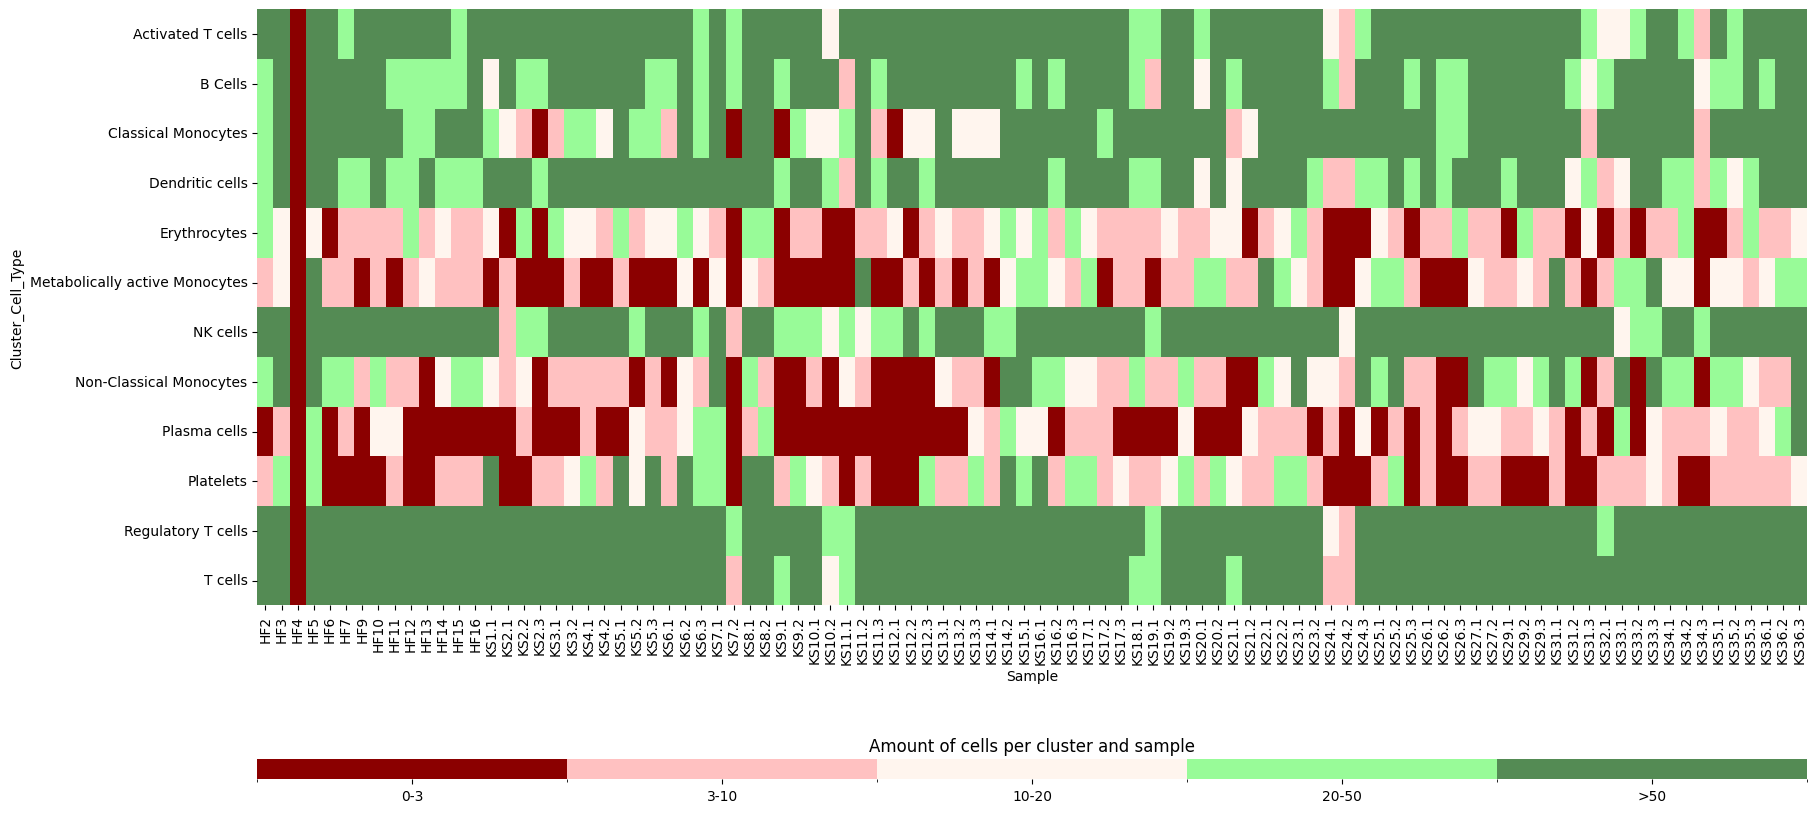

In [58]:
my_colors = ['#8B0000', '#FFC1C1', '#FFF5EE', '#98FB98', '#548B54']
my_cmap = ListedColormap(my_colors)

bounds = [0, 3, 10, 20, 50, 10000]
my_norm = BoundaryNorm(bounds, ncolors=len(my_colors))

#grid_kws = {"height_ratios": (1), "hspace": .1}
# Adjust figsize for a less long and wider plot
fig, (ax, cbar_ax) = plt.subplots(nrows=2, figsize=(20, 10), gridspec_kw={"height_ratios": (15, 0.5), "hspace": .5})
sns.heatmap(data=cells_per_sample_cluster_long.pivot(index='Cluster_Cell_Type', columns='Sample', values='amount_cells'),
            #yticklabels=2, 
            ax=ax,
            cmap=my_cmap,
            norm=my_norm,
            cbar_ax=cbar_ax, xticklabels=True, yticklabels=True,
            cbar_kws={"orientation": "horizontal",  "pad": 0.05})


colorbar = ax.collections[0].colorbar
colorbar.set_ticks([(b0+b1)/2 for b0, b1 in zip(bounds[:-1], bounds[1:])])
colorbar.set_ticklabels(['0-3', '3-10', '10-20', '20-50', '>50'])

# Add title
plt.title("Amount of cells per cluster and sample")

# Save the figure as a PDF to a specific folder
plt.savefig('figures/01_figures/FIG01_Amount_of_Cells_per_Sample_and_Cell_Type'  + '.pdf', bbox_inches='tight')
plt.show()

popup_function_pos("FIG01_Amount_of_Cells_per_Sample_and_Cell_Type generated")

## Calculate gene expression percentages per cluster for thresholding

In [59]:
### Calculate the percentage of cells having non-zero values for each gene per cluster
### will later be used to remove genes that are only expressed in a very low amount of cells

In [60]:
## Generate empty data.frames to store the result in

In [61]:
gene_expr_data = pd.DataFrame()

In [62]:
for j in sc_data_list.keys():
    adata = sc_data_list[j]
    
    for i in pd.unique(adata.obs['cluster_id']):
        cell_type = i
        adata_subset = adata[adata.obs['cluster_id'] == cell_type]

        amount_cells = adata_subset.shape[0]
        ## Calcalte percentage of cells expressiong gene
        amount_cells_expressing_gene = (adata_subset.X > 0).sum(axis= 0)
        perc_cells_expressing_gene = (amount_cells_expressing_gene/ amount_cells) * 100

        data = {
        'perc_cells_expressing_gene': np.ravel(perc_cells_expressing_gene),
        'total_amount_cells_expressing_gene': np.ravel(amount_cells_expressing_gene),
        'gene': adata_subset.var_names,
        'cluster': cell_type,
        'dataset': j
        }

        df = pd.DataFrame(data)

        ### Append data
        gene_expr_data = pd.concat([gene_expr_data, df])

In [63]:
gene_expr_data

,perc_cells_expressing_gene,total_amount_cells_expressing_gene,gene,cluster,dataset
0,0.015557,4,AL627309.1,T cells,Prepared_sc_Data
1,0.019446,5,AL627309.5,T cells,Prepared_sc_Data
2,0.303360,78,LINC01409,T cells,Prepared_sc_Data
3,0.917859,236,LINC01128,T cells,Prepared_sc_Data
4,0.073895,19,LINC00115,T cells,Prepared_sc_Data
...,...,...,...,...,...
26790,0.000000,0,C6orf118,Erythrocytes,Prepared_sc_Data
26791,0.000000,0,LINC01978,Erythrocytes,Prepared_sc_Data
26792,0.000000,0,LINC01879,Erythrocytes,Prepared_sc_Data
26793,0.000000,0,AC008687.4,Erythrocytes,Prepared_sc_Data


In [64]:
### Save results for later filtering
for i in pd.unique(gene_expr_data['dataset']):
    save_data = gene_expr_data[gene_expr_data['dataset'] == i]
    save_data.to_csv(result_path[1] + '/01_results/01_'  + i +  '_Gene_Expr_per_Cell_Type' +  '.csv')
    popup_function_pos('01_'  + i +  '_Gene_Expr_per_Cell_Type' +  '.csv' + " generated")

## Aggregate to pseudobulk

In [65]:
## Aggregate to pseudobulk by cluster and sample_id

In [66]:
adata.raw

In [67]:
for j in sc_data_list.keys():
    adata = sc_data_list[j]
    popup_function_pos("Pseudobulk Aggregation started (this might take some time)")
    adata = dc.get_pseudobulk(
        adata,
        sample_col='sample_id',
        groups_col='cluster_id',
        #layer='counts',
        mode='mean',
        min_cells=0,  # Filter to remove samples by a minimum number of cells in a sample-group pair.
        min_counts=0)   
    
    ## Format as table 
    
    data = adata.to_df()
    data['feature'] = data.index
    
    ## Convert to long format
    data_long = pd.melt(data, id_vars = ['feature'])
    data_long['sample_id'] = data_long['feature'].str.extract(r'^([^_]*)')
    data_long['type'] = data_long['feature'].str.extract(r'_(.*)')
    
    if 'variable' in data_long.columns:
        data_long['variable'] = data_long['variable']
        
    if 'feature_name' in data_long.columns:
        data_long['variable'] = data_long['feature_name']    
    
    data_long['dataset'] = sc_dataset_names[0]
    popup_function_pos("Pseudobulk Aggregation finished")
    
    ## Select relevant columns and save
    data_long = data_long[['sample_id', 'variable', 'value', 'dataset', 'type']]
    data_long.to_csv(result_path[1] + '/01_results/01_' + j + 'Pseudobulk_Table' +'.csv')
    popup_function_pos('01_' + j + 'Pseudobulk_Table' +'.csv' + ' generated')

In [68]:
data_long

,sample_id,variable,value,dataset,type
0,HF10,A1BG,0.011798,Prepared_sc_Data,Activated T cells
1,HF11,A1BG,0.021661,Prepared_sc_Data,Activated T cells
2,HF12,A1BG,0.050873,Prepared_sc_Data,Activated T cells
3,HF13,A1BG,0.017329,Prepared_sc_Data,Activated T cells
4,HF14,A1BG,0.012836,Prepared_sc_Data,Activated T cells
...,...,...,...,...,...
28333247,KS7.2,ZZEF1,0.000000,Prepared_sc_Data,T cells
28333248,KS8.1,ZZEF1,0.007430,Prepared_sc_Data,T cells
28333249,KS8.2,ZZEF1,0.014187,Prepared_sc_Data,T cells
28333250,KS9.1,ZZEF1,0.000000,Prepared_sc_Data,T cells


In [69]:
len(pd.unique(data_long['sample_id']))

96

# Use information about cell types to adjust 02_Pre_Processing_Configs_SC File

In [70]:
### Get configuration name

In [71]:
configuration_name = global_configs['value'][global_configs['parameter'] == 'configuration_name'][2]

In [72]:
configuration_name

'CGS_v1'

In [73]:
## Extract data names from data_long

In [74]:
data_names = pd.unique(data_long['dataset'])

In [75]:
data_names

array(['Prepared_sc_Data'], dtype=object)

In [76]:
## Use cell_counts_per_cluster to define cell-type exclustion

In [77]:
for i in cell_counts_per_cluster.keys():
    data = cell_counts_per_cluster[i]
    exclude = data[data < 50]
    cluster_id =  [ idx for idx in exclude.index]
    data = {
        
    'configuration_name': configuration_name,
    'data_name': i,
    'data_type': 'h5ad',
    'cell_type_exclusion':  ','.join(cluster_id) }
    df = pd.DataFrame(data,index = {'sc_config': 'sc_config'})
    
    

In [78]:
### Set default expression cutoffs

In [79]:
df['cell_expr_thres1'] = '50;10'
df['cell_expr_thres2'] = '40;20'


In [80]:
df

,configuration_name,data_name,data_type,cell_type_exclusion,cell_expr_thres1,cell_expr_thres2
sc_config,CGS_v1,Prepared_sc_Data,h5ad,,50;10,40;20


In [81]:
### Write as new configuration file
df.to_csv('configurations/02_Pre_Processing_Configs_SC.csv', index = False)

In [82]:
### Inform about successful execution
popup_function_pos("01_Prepare_Pseudobulk.ipynb: Execution Finished")

In [83]:
time.sleep(20)
popup_function_info("01_Prepare_Pseudobulk.ipynb")